In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('/content/weather_data_analysis.csv')

print(df.head())
df.info()

         Date  Temperature  Humidity  Precipitation
0  2025-01-01         17.7      73.9           31.6
1  2025-01-02         15.8      78.3            0.0
2  2025-01-03         18.2      76.7            6.1
3  2025-01-04         20.9      77.3            0.0
4  2025-01-05         15.6      71.1            0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           365 non-null    object 
 1   Temperature    362 non-null    float64
 2   Humidity       362 non-null    float64
 3   Precipitation  362 non-null    float64
dtypes: float64(3), object(1)
memory usage: 11.5+ KB


In [9]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date             0
Temperature      3
Humidity         3
Precipitation    3
dtype: int64


In [11]:
df["Temperature"] = df["Temperature"].fillna(df["Temperature"].mean())

df["Humidity"] = df["Humidity"].fillna(df["Humidity"].mean())

df["Precipitation"] = df["Precipitation"].fillna(df["Precipitation"].mean())

In [12]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Date             0
Temperature      0
Humidity         0
Precipitation    0
dtype: int64


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

print("Data types after converting Date:")
print(df.dtypes)

Data types after converting Date:
Date             datetime64[ns]
Temperature             float64
Humidity                float64
Precipitation           float64
dtype: object


In [14]:
print("Descriptive Statistics")
print()

# Temperature
print("Temperature:")
print("Mean:", np.mean(df["Temperature"]))
print("Median:", np.median(df["Temperature"]))
print("Standard Deviation:", np.std(df["Temperature"]))
print()

# Humidity
print("Humidity:")
print("Mean:", np.mean(df["Humidity"]))
print("Median:", np.median(df["Humidity"]))
print("Standard Deviation:", np.std(df["Humidity"]))
print()

# Precipitation
print("Precipitation:")
print("Mean:", np.mean(df["Precipitation"]))
print("Median:", np.median(df["Precipitation"]))
print("Standard Deviation:", np.std(df["Precipitation"]))

Descriptive Statistics

Temperature:
Mean: 25.073480662983425
Median: 24.9
Standard Deviation: 7.0824547664497866

Humidity:
Mean: 64.79834254143647
Median: 65.0
Standard Deviation: 11.18982157429026

Precipitation:
Mean: 4.787569060773481
Median: 0.0
Standard Deviation: 11.418643018576258


In [15]:
df["Month"] = df["Date"].dt.month

print(df[["Date", "Month"]].head())

        Date  Month
0 2025-01-01      1
1 2025-01-02      1
2 2025-01-03      1
3 2025-01-04      1
4 2025-01-05      1


In [16]:
monthly_avg = df.groupby("Month")[["Temperature", "Humidity", "Precipitation"]].mean()

print("Monthly Average Weather Data:")
display(monthly_avg)

Monthly Average Weather Data:


,Temperature,Humidity,Precipitation
Month,,,
1,16.848387,76.622581,2.054839
2,19.941910,72.789286,0.917857
3,24.367742,64.845108,4.958065
4,29.086667,59.563333,2.166252
5,31.902370,54.480645,5.380645
6,34.473333,50.623333,9.316667
7,33.332258,54.977366,5.241935
8,29.916129,59.338710,7.129032
9,24.813333,65.370000,11.252919


In [17]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)

print("Season column added:")
display(df[["Date", "Month", "Season"]].head())

Season column added:


,Date,Month,Season
0,2025-01-01,1,Winter
1,2025-01-02,1,Winter
2,2025-01-03,1,Winter
3,2025-01-04,1,Winter
4,2025-01-05,1,Winter


In [18]:
seasonal_avg = df.groupby("Season")[["Temperature", "Humidity", "Precipitation"]].mean()

print("Seasonal Average Weather Data:")
display(seasonal_avg)

Seasonal Average Weather Data:


,Temperature,Humidity,Precipitation
Season,,,
Autumn,21.586522,69.678004,5.435991
Spring,28.445364,59.630417,4.190082
Summer,32.553261,55.027156,7.206522
Winter,17.506372,75.135556,2.270000


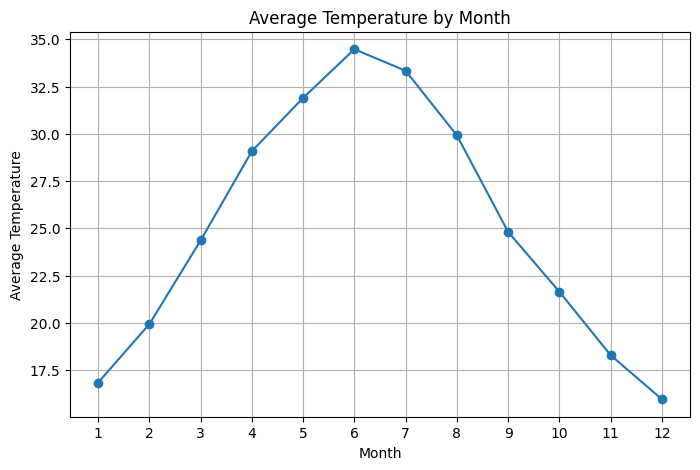

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg["Temperature"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Temperature")
plt.title("Average Temperature by Month")
plt.xticks(range(1, 13))

plt.grid(True)
plt.show()

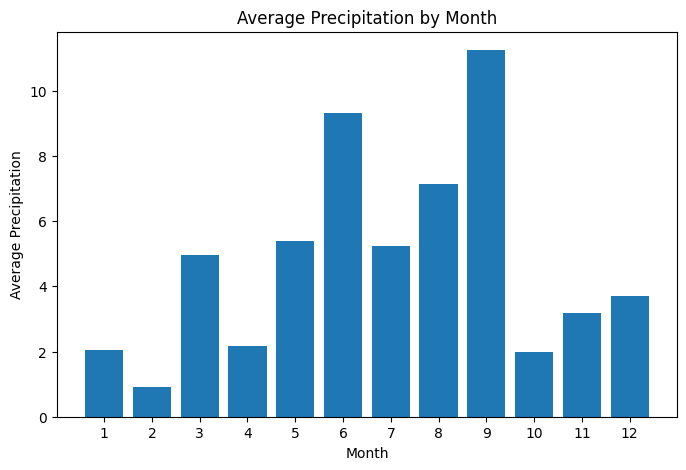

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    monthly_avg.index,
    monthly_avg["Precipitation"]
)

plt.xlabel("Month")
plt.ylabel("Average Precipitation")
plt.title("Average Precipitation by Month")
plt.xticks(range(1, 13))

plt.show()

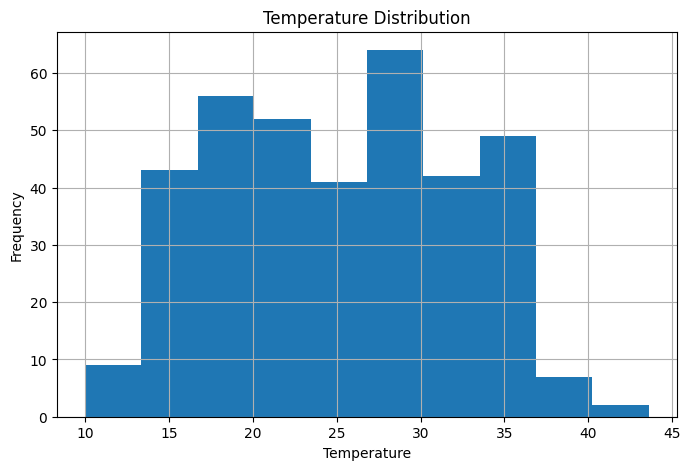

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Temperature"],
    bins=10
)

plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.title("Temperature Distribution")

plt.grid(True)
plt.show()

In [22]:
# Calculate mean and standard deviation
temp_mean = np.mean(df["Temperature"])
temp_std = np.std(df["Temperature"])

precip_mean = np.mean(df["Precipitation"])
precip_std = np.std(df["Precipitation"])


# Find extreme temperature days
extreme_temperature = df[
    np.abs(df["Temperature"] - temp_mean) > 2 * temp_std
]


# Find extreme precipitation days
extreme_precipitation = df[
    df["Precipitation"] > precip_mean + 2 * precip_std
]


print("Extreme Temperature Days:")
display(extreme_temperature[["Date", "Temperature"]])


print("Extreme Precipitation Days:")
display(extreme_precipitation[["Date", "Precipitation"]])

Extreme Temperature Days:


,Date,Temperature
41,2025-02-11,10.0
156,2025-06-06,39.3
167,2025-06-17,39.7
179,2025-06-29,42.1
209,2025-07-29,43.6


Extreme Precipitation Days:


,Date,Precipitation
0,2025-01-01,31.6
83,2025-03-25,64.8
84,2025-03-26,70.0
135,2025-05-16,33.9
140,2025-05-21,28.0
153,2025-06-03,37.7
156,2025-06-06,60.0
221,2025-08-10,85.0
245,2025-09-03,40.5
266,2025-09-24,38.8


In [23]:
print("Weather Data Analysis Project Completed")
print("---------------------------------------")
print("Total Records:", len(df))
print("Date Range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Average Temperature:", round(df["Temperature"].mean(), 2))
print("Average Humidity:", round(df["Humidity"].mean(), 2))
print("Average Precipitation:", round(df["Precipitation"].mean(), 2))
print("Extreme Temperature Days:", len(extreme_temperature))
print("Extreme Precipitation Days:", len(extreme_precipitation))

Weather Data Analysis Project Completed
---------------------------------------
Total Records: 365
Date Range: 2025-01-01 to 2025-12-31
Average Temperature: 25.07
Average Humidity: 64.8
Average Precipitation: 4.79
Extreme Temperature Days: 5
Extreme Precipitation Days: 13
